### Sieci konwolucyjne (CNN)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.initializers import HeNormal

from PIL import Image
import os


Rozmiar danych treningowych: (60000, 28, 28, 1)
Rozmiar etykiet treningowych: (60000, 10)
Rozmiar danych testowych: (10000, 28, 28, 1)
Rozmiar etykiet testowych: (10000, 10)


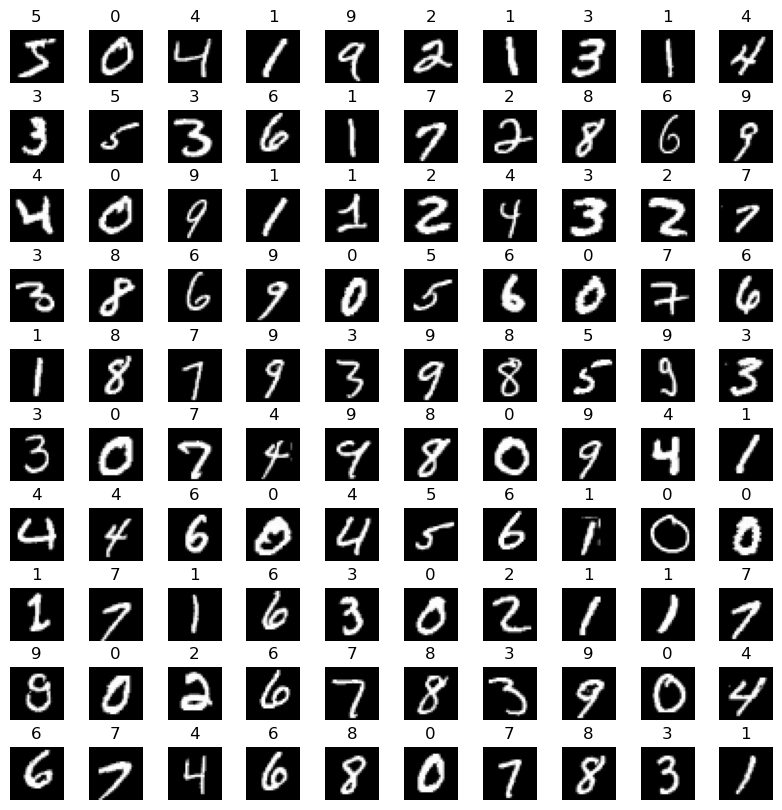

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Rozmiar danych treningowych:", x_train.shape)
print("Rozmiar etykiet treningowych:", y_train.shape)
print("Rozmiar danych testowych:", x_test.shape)
print("Rozmiar etykiet testowych:", y_test.shape)

rows = 10
cols = 10

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
axes = axes.ravel()
for i in range(rows * cols):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"{y_train[i].argmax()}")
    axes[i].axis('off')
plt.subplots_adjust(hspace=0.5)
plt.show()


In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 64)                1

In [ ]:
model = models.Sequential([
    # Blok 1
    layers.Conv2D(32, kernel_size=5, activation='relu', padding='same', input_shape=(28, 28, 1), kernel_initializer=HeNormal()),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    # Blok 2
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same', 
           kernel_initializer=HeNormal()),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    # Gęste warstwy
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_initializer=HeNormal()),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Epoch 1/5
750/750 [==============================] - 58s 76ms/step - loss: 0.1991 - accuracy: 0.9402 - val_loss: 0.0673 - val_accuracy: 0.9814
Epoch 2/5
750/750 [==============================] - 58s 77ms/step - loss: 0.0601 - accuracy: 0.9817 - val_loss: 0.0566 - val_accuracy: 0.9835
Epoch 3/5
750/750 [==============================] - 41s 55ms/step - loss: 0.0415 - accuracy: 0.9876 - val_loss: 0.0470 - val_accuracy: 0.9855
Epoch 4/5
750/750 [==============================] - 39s 53ms/step - loss: 0.0322 - accuracy: 0.9902 - val_loss: 0.0470 - val_accuracy: 0.9878
Epoch 5/5
750/750 [==============================] - 46s 61ms/step - loss: 0.0254 - accuracy: 0.9919 - val_loss: 0.0460 - val_accuracy: 0.9860


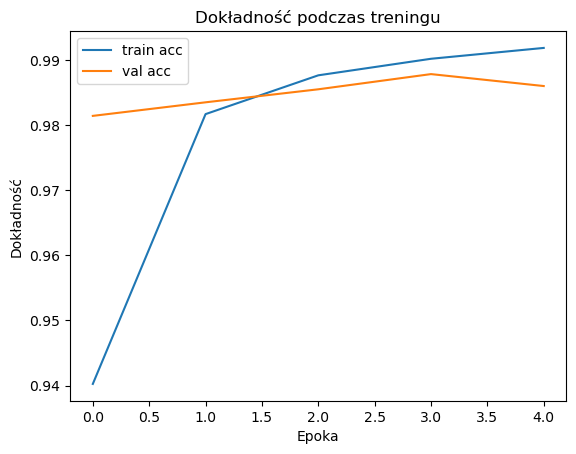

In [4]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Wykresy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.title('Dokładność podczas treningu')
plt.show()

In [5]:
custom_images_dir = './cyfry_testowe/'
for file_name in os.listdir(custom_images_dir):
    if file_name.endswith('.png'):
        img = Image.open(os.path.join(custom_images_dir, file_name)).convert('L').resize((28,28))
        img = np.array(img).astype("float32") / 255.0
        img = img.reshape(1, 28, 28, 1)
        pred = model.predict(img)
        print(f"{file_name} Rozpoznano jako: {np.argmax(pred)}")

1/1 [==============================] - 0s 232ms/step
cztery_1.png Rozpoznano jako: 5
1/1 [==============================] - 0s 61ms/step
cztery_2.png Rozpoznano jako: 4
1/1 [==============================] - 0s 59ms/step
cztery_3.png Rozpoznano jako: 9
1/1 [==============================] - 0s 61ms/step
dwa_1.png Rozpoznano jako: 2
1/1 [==============================] - 0s 66ms/step
dwa_2.png Rozpoznano jako: 3
1/1 [==============================] - 0s 64ms/step
jeden_1.png Rozpoznano jako: 1
1/1 [==============================] - 0s 45ms/step
jeden_2.png Rozpoznano jako: 1
1/1 [==============================] - 0s 32ms/step
osiem_1.png Rozpoznano jako: 3
1/1 [==============================] - 0s 48ms/step
piec_1.png Rozpoznano jako: 5
1/1 [==============================] - 0s 31ms/step
szesc_1.png Rozpoznano jako: 8
1/1 [==============================] - 0s 48ms/step
trzy_1.png Rozpoznano jako: 2
1/1 [==============================] - 0s 30ms/step
trzy_2.png Rozpoznano jako: 3
